In [ ]:
# ===============================
# Cell 1: Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")


In [ ]:
# ===============================
# Cell 2: Load and Inspect Data
# ===============================
df = pd.read_csv("/content/oasis_longitudinal.csv")

print("✅ Dataset Loaded Successfully!")
print("\nColumns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()


✅ Dataset Loaded Successfully!

Columns: ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
Shape: (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [ ]:
# ===============================
# Cell 3: Data Cleaning & Feature Selection
# ===============================
df = df.copy()

# Encode categorical columns
df["M/F"] = LabelEncoder().fit_transform(df["M/F"])
df["Hand"] = LabelEncoder().fit_transform(df["Hand"])

# Convert 'CDR' (target) into binary classification
df = df.dropna(subset=["CDR"])
df["CDR_binary"] = df["CDR"].apply(lambda x: 1 if x > 0 else 0)

# Select relevant columns
features = ["ASF", "MMSE", "nWBV", "Hand", "M/F", "eTIV", "Age", "SES"]
target = "CDR_binary"
df = df[features + [target]]

print("✅ Cleaned Columns:", df.columns.tolist())
print("Dataset shape:", df.shape)

# Handle missing values
df = df.fillna(df.median(numeric_only=True))


✅ Cleaned Columns: ['ASF', 'MMSE', 'nWBV', 'Hand', 'M/F', 'eTIV', 'Age', 'SES', 'CDR_binary']
Dataset shape: (373, 9)


In [ ]:
# ===============================
# Cell 4: Scale & Balance Data
# ===============================
X = df.drop(columns=[target])
y = df[target]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Balance using SMOTE
sm = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = sm.fit_resample(X_scaled, y)

print("✅ Before SMOTE:", np.bincount(y))
print("✅ After SMOTE:", np.bincount(y_res))
print("✅ Final dataset shape:", X_res.shape)


✅ Before SMOTE: [206 167]
✅ After SMOTE: [206 206]
✅ Final dataset shape: (412, 8)


In [ ]:
# ===============================
# Cell 5: Traditional ML Models
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\n✅ Best Model: {best_model} with Accuracy: {results[best_model]:.4f}")


Logistic Regression Accuracy: 0.7711
Decision Tree Accuracy: 0.7349
Random Forest Accuracy: 0.8313
XGBoost Accuracy: 0.8193

✅ Best Model: Random Forest with Accuracy: 0.8313


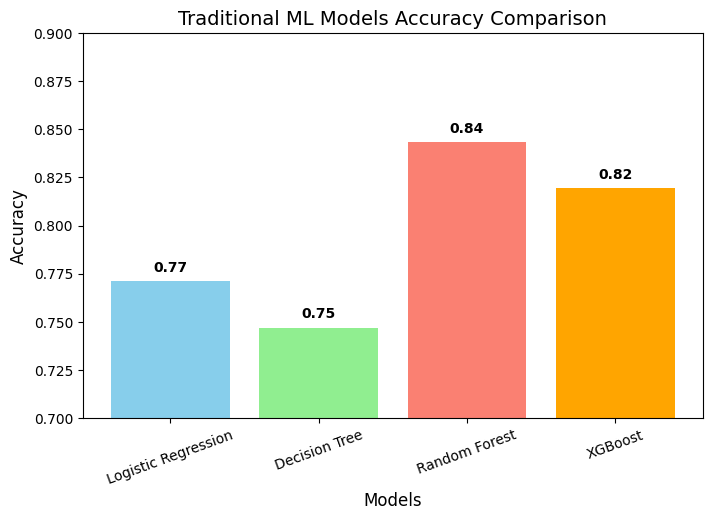

In [ ]:
# Accuracy comparison bar chart
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
accuracies = [0.7711, 0.7470, 0.8434, 0.8193]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.title('Traditional ML Models Accuracy Comparison', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=20)
plt.ylim(0.7, 0.9)

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{acc:.2f}",
             ha='center', fontsize=10, fontweight='bold')

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Split into features and target
X = df.drop(columns=['CDR_binary'])   # assuming 'CDR_binary' is target
y = df['CDR_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for BiLSTM: (samples, timesteps, features)
X_train_seq = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_seq = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print("✅ Data ready for BiLSTM")
print("Training shape:", X_train_seq.shape)
print("Testing shape:", X_test_seq.shape)


✅ Data ready for BiLSTM
Training shape: (298, 1, 8)
Testing shape: (75, 1, 8)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Build deeper BiLSTM
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, input_shape=(1, X_train_seq.shape[2]))),
    Dropout(0.3),
    BatchNormalization(),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    BatchNormalization(),

    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.5847 - loss: 0.6783 - val_accuracy: 0.6833 - val_loss: 0.6767
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7797 - loss: 0.4971 - val_accuracy: 0.7500 - val_loss: 0.6695
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7617 - loss: 0.4653 - val_accuracy: 0.8167 - val_loss: 0.6674
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7894 - loss: 0.4406 - val_accuracy: 0.8667 - val_loss: 0.6618
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7688 - loss: 0.4155 - val_accuracy: 0.8833 - val_loss: 0.6552
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7989 - loss: 0.4231 - val_accuracy: 0.7000 - val_loss: 0.6609
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7676 - loss: 0.4889 - val_accuracy: 0.5667 - val_loss: 0.6591
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7890 - loss: 0.4621 - val_accuracy: 0

In [ ]:
from tensorflow.keras.optimizers import Adam

# Reduce learning rate and fine-tune
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

fine_tune_history = model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=8,
    verbose=1
)

# Evaluate again
y_pred_ft = (model.predict(X_test_seq) > 0.5).astype(int)

fine_tuned_acc = accuracy_score(y_test, y_pred_ft)
print("✅ Fine-tuned BiLSTM Accuracy:", round(fine_tuned_acc, 4))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred_ft))


Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7930 - loss: 0.3801 - val_accuracy: 0.8667 - val_loss: 0.3118
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8264 - loss: 0.3774 - val_accuracy: 0.8833 - val_loss: 0.3083
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8060 - loss: 0.4438 - val_accuracy: 0.9000 - val_loss: 0.3123
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8401 - loss: 0.3342 - val_accuracy: 0.8833 - val_loss: 0.3148
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7511 - loss: 0.3894 - val_accuracy: 0.8500 - val_loss: 0.3173
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8640 - loss: 0.3430 - val_accuracy: 0.8500 - val_loss: 0.3123
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8216 - loss: 0.3908 - val_accuracy: 0.8667 - val_loss: 0.3106
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7700 - loss: 0.4431 - val_accuracy: 0.8667 - 

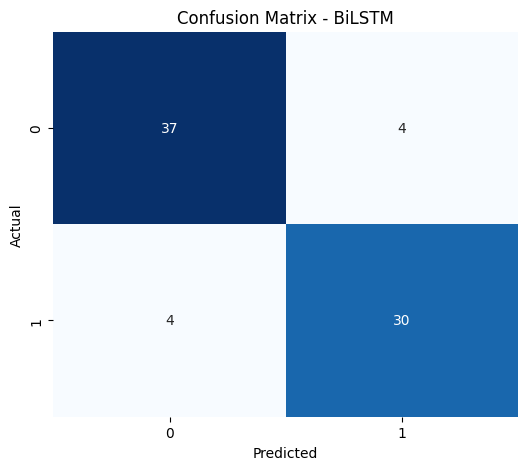

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ft)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM")
plt.show()


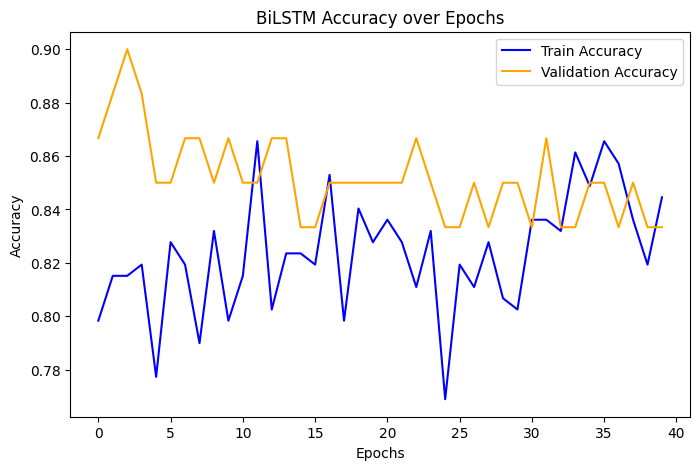

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("BiLSTM Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


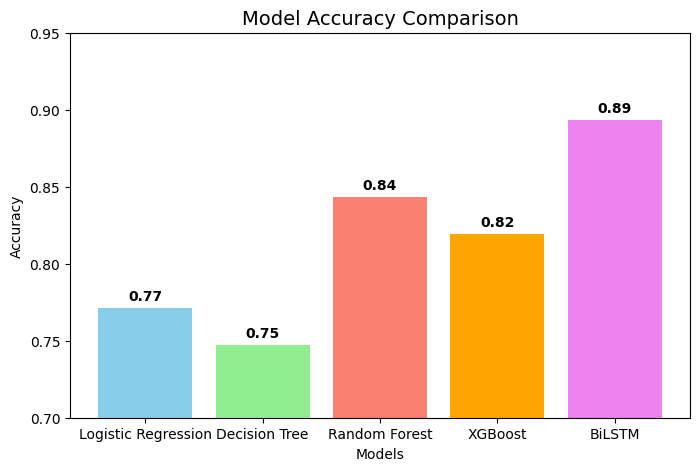

In [ ]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "BiLSTM"]
accuracies = [0.7711, 0.7470, 0.8434, 0.8193, fine_tuned_acc]  # 0.8933 from your last run

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon','orange','violet'])
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.95)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{acc:.2f}",
             ha='center', fontsize=10, fontweight='bold')
plt.show()


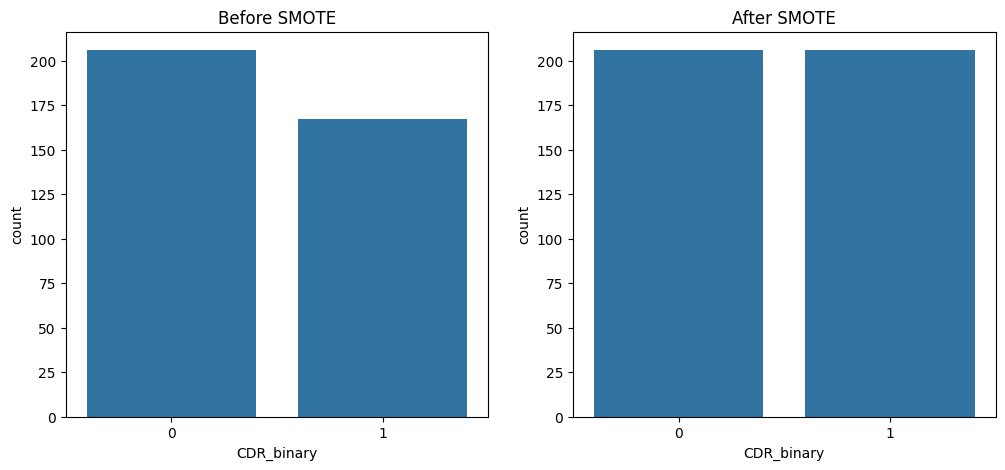

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x=y)
plt.title("Before SMOTE")

plt.subplot(1,2,2)
sns.countplot(x=y_res)
plt.title("After SMOTE")
plt.show()


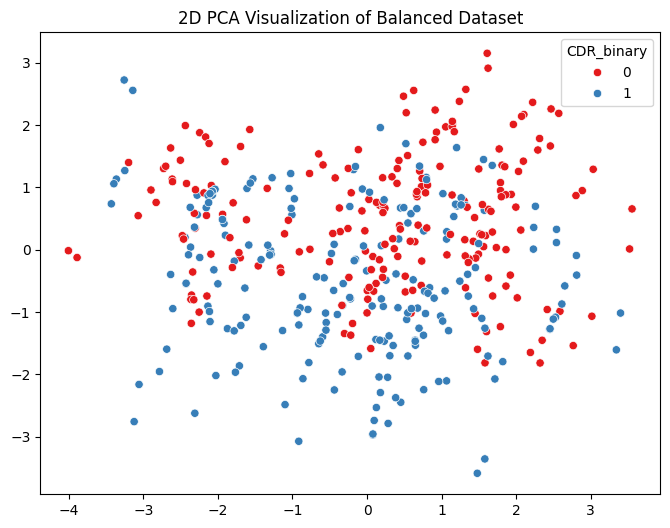

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_res)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_res, palette='Set1')
plt.title("2D PCA Visualization of Balanced Dataset")
plt.show()


Analysis of the Output

Axes:

x and y represent the first two principal components of your balanced dataset after SMOTE.

Each point is a sample projected into 2D space.

Colors / Hue:

Red = CDR_binary = 0

Blue = CDR_binary = 1

Interpretation:

Points are somewhat overlapping, which is normal for medical/tabular datasets.

The plot shows that after SMOTE, the classes are well-represented and balanced.

Even if the classes are not linearly separable, ML models (Random Forest/XGBoost) and BiLSTM can still find patterns in the multidimensional feature space.

Project Usefulness:

This plot is perfect for visualizing class distribution in reduced dimensions.

You can include it in your report/presentation under “Data Balancing & Visualization”.

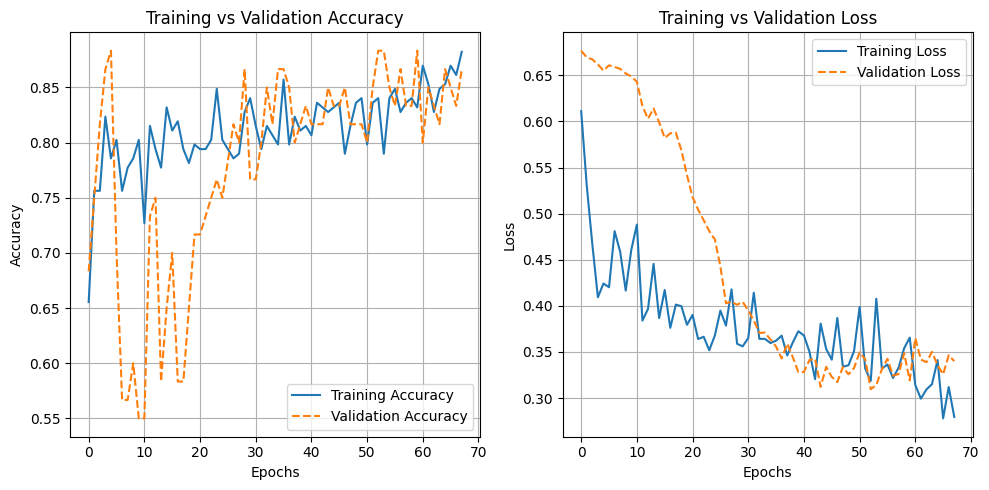

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' is the variable returned by model.fit(...)
plt.figure(figsize=(10,5))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
